# 05 · Modelos y evaluación responsable

**Edición docente · 8 de octubre de 2026 · Fundamentos de Business Analytics**

**Profundización de la guía maestra · puente hacia Modelos Predictivos · 150–180 minutos.**
Compararás regresión, clasificación y clustering; separarás entrenamiento, validación y prueba;
ajustarás transformaciones exclusivamente con entrenamiento y evaluarás costos de errores.

**Cómo trabajar:** ejecuta desde la primera celda. En cada simulador formula primero una predicción,
cambia un parámetro y justifica la diferencia. Los datos son casos docentes del repositorio o
simulaciones identificadas; no permiten inferir resultados de empresas reales.

Los controles requieren JupyterLab con `ipywidgets` y un kernel activo; las salidas guardadas permiten
leer los ejemplos sin ejecutar. Las funciones también pueden llamarse directamente, con lo que
el ejercicio sigue siendo utilizable si el visor no muestra widgets.

[Guía maestra](../guia_maestra_ba.html) · [Manual científico](../material_propio/FBA_manual_cientifico.pdf)

### Antes de ejecutar

Profundización · 90–120 min orientativos.

**Objetivo:** Comparar un modelo con una referencia usando datos reservados.

**Preparación:** Módulos 01–02 y noción de probabilidad; ejecutar celdas en orden.

**Ejemplo de referencia:** Separar ajuste y evaluación y observar cómo cambia una decisión al mover el umbral.

**Práctica:** Justificar un costo distinto de falso negativo y comprobar su efecto en la recomendación.

**Criterio de logro:** Informar partición, referencia, métrica, costo y un límite de generalización.

[Guía y secuencia](../guia_maestra_ba.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/FBA_manual_cientifico.html#sec-modelos)

In [1]:
from pathlib import Path
import sys
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "_transversal" / "datos").is_dir()), None)
if RAIZ is None:
    raise FileNotFoundError("Abra Jupyter desde el repositorio completo o una subcarpeta.")
CURSO = RAIZ / "01_Fundamentos_Business_Analytics"
sys.path.insert(0, str(CURSO / "reproducibilidad"))
from fba_recursos import ventas, resumen_ventas, pregunta, DATOS, SEMILLA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
%matplotlib inline
plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18})
pd.set_option("display.max_columns", 14)
df = ventas()
print(f"Python {sys.version.split()[0]} · pandas {pd.__version__} · {len(df)} transacciones")

Python 3.12.13 · pandas 3.0.6 · 180 transacciones


<a id="regresion"></a>

## Regresión lineal y límites

Para $Y=\beta_0+\beta_1X+\varepsilon$, mínimos cuadrados minimiza la suma de residuos al cuadrado.
Con intercepto y $X$ variable, $\hat\beta_1=\sum(x_i-\bar x)(y_i-\bar y)/\sum(x_i-\bar x)^2$.
Estimar una asociación no demuestra un efecto causal. Examina residuos, rango observado y variables
omitidas. El RMSE queda en unidades de la respuesta; $R^2$ compara con la predicción por la media
del conjunto evaluado y puede ser negativo fuera de muestra.

El ejemplo sintético permite conocer el mecanismo generador. Luego se pasa a un caso de clasificación
del banco compartido. No se usan las filas de test para decidir transformaciones, hiperparámetros ni umbral.

Pendiente=2.646; intercepto=14.828


MAE     18.341236
RMSE    23.231895
R2       0.896361
dtype: float64

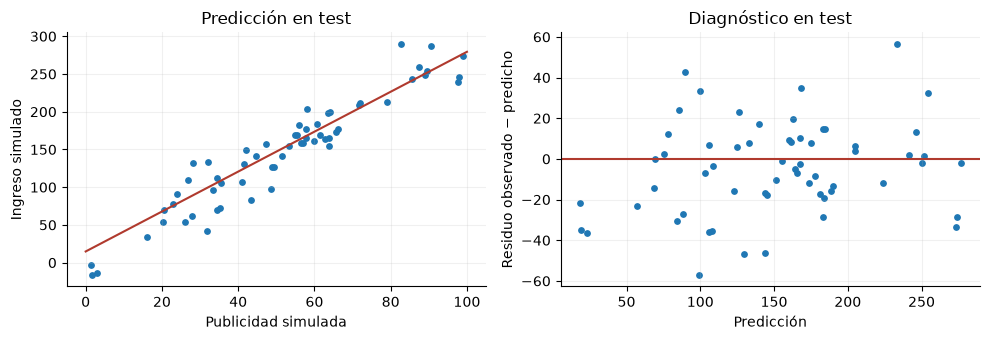

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
rng=np.random.default_rng(SEMILLA)
publicidad=rng.uniform(0,100,240)
ingreso=20+2.5*publicidad+rng.normal(0,25,len(publicidad))
Xtr,Xte,ytr,yte=train_test_split(publicidad.reshape(-1,1),ingreso,test_size=.25,random_state=SEMILLA)
reg=LinearRegression().fit(Xtr,ytr)
pred=reg.predict(Xte)
print(f"Pendiente={reg.coef_[0]:.3f}; intercepto={reg.intercept_:.3f}")
display(pd.Series({"MAE":mean_absolute_error(yte,pred),"RMSE":root_mean_squared_error(yte,pred),
                    "R2":r2_score(yte,pred)}))
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
axes[0].scatter(Xte[:,0],yte,s=15);xx=np.array([[0],[100]])
axes[0].plot(xx[:,0],reg.predict(xx),color="#b03a2e")
axes[0].set(xlabel="Publicidad simulada",ylabel="Ingreso simulado",title="Predicción en test")
axes[1].scatter(pred,yte-pred,s=15);axes[1].axhline(0,color="#b03a2e")
axes[1].set(xlabel="Predicción",ylabel="Residuo observado − predicho",title="Diagnóstico en test")
plt.tight_layout();plt.show()

<a id="clasificacion"></a>

## Clasificación y separación honesta

FinCordillera contiene 950 clientes simulados y un indicador `churn`. Quitamos `cliente_id` de predictores.
La primera partición reserva 20% de test; la segunda divide el 80% restante en entrenamiento y
validación, obteniendo 60/20/20. La estratificación preserva aproximadamente la proporción de clases.
Si fueran observaciones temporales o clientes repetidos, se necesitarían otras particiones.

La regresión logística estima probabilidades mediante una función sigmoide. KNN compara distancias
y exige una escala razonable. Un árbol divide regiones del espacio y un bosque promedia árboles.
Todas las transformaciones aprendidas se ajustan dentro del pipeline; las categorías desconocidas
se manejan explícitamente. Se comparan en validación, se selecciona una vez y se informa test al final.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score,average_precision_score,accuracy_score,
                             precision_score,recall_score,f1_score,confusion_matrix)
banco=pd.read_csv(DATOS / "fincordillera" / "originales" / "fincordillera_clientes.csv")
X=banco.drop(columns=["cliente_id","churn"]); y=banco.churn.astype(int)
Xdev,Xtest,ydev,ytest=train_test_split(X,y,test_size=.20,stratify=y,random_state=SEMILLA)
Xtrain,Xval,ytrain,yval=train_test_split(Xdev,ydev,test_size=.25,stratify=ydev,random_state=SEMILLA)
assert set(Xtrain.index).isdisjoint(Xval.index)
assert set(Xdev.index).isdisjoint(Xtest.index)
numericas=Xtrain.select_dtypes(include="number").columns.tolist()
categoricas=[c for c in X.columns if c not in numericas]
def preproceso():
    return ColumnTransformer([
     ("num",Pipeline([("imputar",SimpleImputer(strategy="median")),("escalar",StandardScaler())]),numericas),
     ("cat",Pipeline([("imputar",SimpleImputer(strategy="most_frequent")),
                       ("codificar",OneHotEncoder(handle_unknown="ignore",sparse_output=False))]),categoricas)])
candidatos={"Base":DummyClassifier(strategy="prior"),
 "Logística":LogisticRegression(max_iter=1500,random_state=SEMILLA),
 "Árbol":DecisionTreeClassifier(max_depth=4,min_samples_leaf=15,random_state=SEMILLA),
 "KNN":KNeighborsClassifier(n_neighbors=15),
 "Bosque":RandomForestClassifier(n_estimators=100,max_depth=6,min_samples_leaf=8,random_state=SEMILLA,n_jobs=1)}
modelos={}; resultados=[]
for nombre,estimador in candidatos.items():
    modelo=Pipeline([("preparar",preproceso()),("modelo",estimador)]).fit(Xtrain,ytrain)
    pv=modelo.predict_proba(Xval)[:,1]
    resultados.append({"modelo":nombre,"AP_validacion":average_precision_score(yval,pv),
                       "ROC_AUC_validacion":roc_auc_score(yval,pv)})
    modelos[nombre]=modelo
comparacion=pd.DataFrame(resultados).set_index("modelo").sort_values("AP_validacion",ascending=False)
display(comparacion)
print("Tamaños train/validación/test:",len(Xtrain),len(Xval),len(Xtest))

,AP_validacion,ROC_AUC_validacion
modelo,,
Logística,0.501156,0.710921
Bosque,0.425539,0.669880
KNN,0.414604,0.663407
Árbol,0.378426,0.648533
Base,0.278947,0.500000


Tamaños train/validación/test: 570 190 190


<a id="evaluacion"></a>

## Matriz de confusión, umbral y costo

El evento positivo es abandono. Precision responde qué fracción de alertas corresponde al evento;
recall, qué fracción de eventos se detecta. Accuracy puede ocultar una minoría. F1 combina precisión
y recall y omite verdaderos negativos. ROC-AUC evalúa ordenamiento global; average precision (AP)
resume la curva precisión–recall y depende de prevalencia. Ninguna equivale a calibración probabilística.

Supongamos costo de falso negativo 5 y falso positivo 1, en unidades de pérdida didáctica.
El costo promedio es $(5FN+FP)/n$. El simulador usa solo validación. La grilla incluye umbrales
menores que 0 y mayores que 1 para representar las decisiones «todos positivos» y «todos negativos».
Las métricas de denominador cero se reportan como 0 aquí por una convención explícita de comparación.

In [4]:
elegido=comparacion.index[0]
modelo_final=modelos[elegido]
pv=modelo_final.predict_proba(Xval)[:,1]
def metricas_umbral(y_real,prob,umbral,c_fn=5.,c_fp=1.):
    decision=np.asarray(prob)>=umbral
    tn,fp,fn,tp=confusion_matrix(y_real,decision,labels=[0,1]).ravel()
    return {"TN":int(tn),"FP":int(fp),"FN":int(fn),"TP":int(tp),
            "accuracy":accuracy_score(y_real,decision),
            "precision":precision_score(y_real,decision,zero_division=0),
            "recall":recall_score(y_real,decision,zero_division=0),
            "F1":f1_score(y_real,decision,zero_division=0),
            "costo_medio":(c_fn*fn+c_fp*fp)/len(y_real)}
grilla=np.r_[-.001,np.linspace(0,1,101),1.001]
costos=np.array([metricas_umbral(yval,pv,t)["costo_medio"] for t in grilla])
umbral=float(grilla[np.argmin(costos)])
def explorar_umbral(t=.5):
    m=metricas_umbral(yval,pv,t)
    display(pd.Series(m,name="Validación · "+elegido));return m
explorar_umbral(umbral)
widgets.interact(explorar_umbral,t=widgets.FloatSlider(value=.5,min=0,max=1,step=.02));
print(f"Selección congelada: {elegido}; umbral={umbral:.3f}")

TN             50.000000
FP             87.000000
FN              4.000000
TP             49.000000
accuracy        0.521053
precision       0.360294
recall          0.924528
F1              0.518519
costo_medio     0.563158
Name: Validación · Logística, dtype: float64

interactive(children=(FloatSlider(value=0.5, description='t', max=1.0, step=0.02), Output()), _dom_classes=('w…

Selección congelada: Logística; umbral=0.140


In [5]:
# Se consulta test una vez después de fijar modelo, costos y umbral con desarrollo.
ptest=modelo_final.predict_proba(Xtest)[:,1]
informe_test=metricas_umbral(ytest,ptest,umbral)
informe_test["ROC_AUC"]=roc_auc_score(ytest,ptest)
informe_test["AP"]=average_precision_score(ytest,ptest)
display(pd.Series(informe_test,name="Evaluación final en test"))
assert sum(informe_test[k] for k in ["TN","FP","FN","TP"])==len(ytest)
print("El modelo no se reajusta después de observar estos resultados.")

TN             44.000000
FP             93.000000
FN              5.000000
TP             48.000000
accuracy        0.484211
precision       0.340426
recall          0.905660
F1              0.494845
costo_medio     0.621053
ROC_AUC         0.727723
AP              0.580163
Name: Evaluación final en test, dtype: float64

El modelo no se reajusta después de observar estos resultados.


<a id="sobreajuste"></a>

## Sobreajuste y complejidad

Una brecha entrenamiento–validación es una señal compatible con sobreajuste, pero también puede
responder a deriva o particiones distintas. El control cambia profundidad y compara esas dos muestras,
sin usar el test reservado. Escalar el problema con un bosque no garantiza mejor desempeño.
El modelo base es necesario: un resultado útil debe superar una alternativa simple bajo la métrica adecuada.

In [6]:
def explorar_profundidad(profundidad=4):
    arbol=Pipeline([("preparar",preproceso()),("modelo",DecisionTreeClassifier(
        max_depth=profundidad,random_state=SEMILLA))]).fit(Xtrain,ytrain)
    valores={"entrenamiento":accuracy_score(ytrain,arbol.predict(Xtrain)),
             "validacion":accuracy_score(yval,arbol.predict(Xval))}
    display(pd.Series(valores,name="Accuracy")); return valores
explorar_profundidad()
widgets.interact(explorar_profundidad,profundidad=(1,18,1));

entrenamiento    0.770175
validacion       0.721053
Name: Accuracy, dtype: float64

interactive(children=(IntSlider(value=4, description='profundidad', max=18, min=1), Output()), _dom_classes=('…

<a id="clustering"></a>

## Clustering sin variable objetivo

K-means minimiza distancias euclidianas al cuadrado a centroides. La escala domina esa distancia
si no se controla. Usamos edad, ingreso y uso de aplicación, excluyendo el resultado churn.
Un cluster es una partición del espacio definido, no un segmento «verdadero» descubierto de forma
automática. Se elige $k$ por estabilidad, interpretación, finalidad y restricciones, no solo por inercia,
que no aumenta al añadir clusters. Las etiquetas numéricas no tienen orden intrínseco.

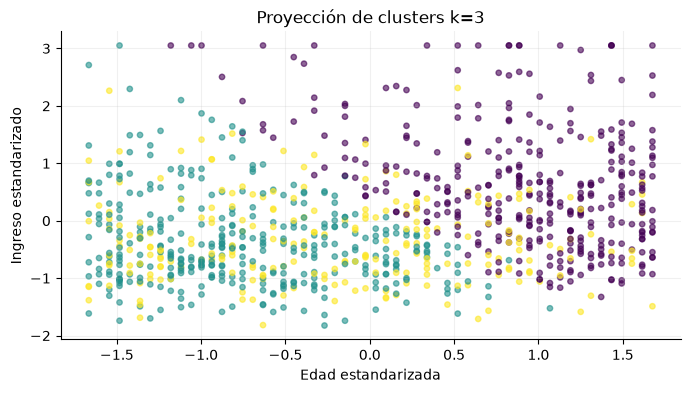

,edad,ingreso_mensual_clp,uso_app_movil_mensual
cluster,,,
0,61.420904,1.374729e+06,7.322034
1,34.208791,9.553187e+05,6.351648
2,42.689655,9.780690e+05,11.547414


Inercia=1624.0; silueta=0.265


interactive(children=(IntSlider(value=3, description='k', max=6, min=2), Output()), _dom_classes=('widget-inte…

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
variables_cluster=["edad","ingreso_mensual_clp","uso_app_movil_mensual"]
Z=StandardScaler().fit_transform(banco[variables_cluster])
def explorar_clusters(k=3):
    modelo=KMeans(n_clusters=k,n_init=10,random_state=SEMILLA).fit(Z)
    perfil=banco[variables_cluster].assign(cluster=modelo.labels_).groupby("cluster").mean()
    fig,ax=plt.subplots();ax.scatter(Z[:,0],Z[:,1],c=modelo.labels_,cmap="viridis",s=15,alpha=.6)
    ax.set(xlabel="Edad estandarizada",ylabel="Ingreso estandarizado",title=f"Proyección de clusters k={k}")
    plt.show();display(perfil)
    print(f"Inercia={modelo.inertia_:.1f}; silueta={silhouette_score(Z,modelo.labels_):.3f}")
    return modelo.labels_
etiquetas=explorar_clusters()
widgets.interact(explorar_clusters,k=(2,6,1));

### Ejercicios resueltos y preguntas para docentes

1. Si TN=90, FP=10, FN=20 y TP=30, accuracy=0,80; precision=0,75; recall=0,60;
   F1=2/3 y costo medio con FN=5, FP=1 igual a 110/150. Reconstruye cada denominador.
2. ¿Por qué no escalar antes de particionar? La media y desviación incorporarían información del
   conjunto reservado. Se ajustan con entrenamiento y solo se aplican a validación y test.
3. ¿Optimizar umbral en test y reportarlo allí es válido? No: test habría participado en la selección.
4. ¿Un buen ROC-AUC asegura probabilidades calibradas? No: evalúa orden, no exactitud de probabilidades.
5. Propón qué cambiar para eventos temporales, costos inciertos y revisión de sesgos por segmento.
   **Respuesta orientativa:** partición temporal, sensibilidad de costos y evaluación desagregada con
   tamaños e incertidumbre. Las diferencias de métricas no resuelven por sí solas una evaluación ética.

**Extensión de postgrado:** validación anidada, intervalos de métricas y cambio de distribución;
son tareas posteriores, no resultados que esta demostración ya haya certificado.

In [8]:
auto_05=pregunta("El umbral se eligió observando las etiquetas de test. ¿Qué ocurre?",
 ["Se conserva una evaluación independiente", "Test pasó a participar en la selección",
  "Solo importa que la muestra sea grande"],1,
 "Se necesita otra muestra final independiente o rediseñar el procedimiento de validación.")
reales=np.array([0]*100+[1]*50)
prob=np.array([0]*90+[1]*10+[0]*20+[1]*30,dtype=float)
prueba=metricas_umbral(reales,prob,.5)
assert np.isclose(prueba["accuracy"],.8) and np.isclose(prueba["precision"],.75)
assert np.isclose(prueba["recall"],.6) and np.isclose(prueba["F1"],2/3)
assert np.isclose(prueba["costo_medio"],110/150)
assert len(etiquetas)==len(banco)
print("Comprobaciones del laboratorio 05: OK")

Comprobaciones del laboratorio 05: OK


### Referencias

[James, Witten, Hastie, Tibshirani y Taylor: ISLP](https://www.statlearning.com/),
[scikit-learn: errores frecuentes y fuga de información](https://scikit-learn.org/stable/common_pitfalls.html)
y [métricas de evaluación](https://scikit-learn.org/stable/modules/model_evaluation.html).
Los ejemplos, particiones y decisiones de esta práctica son propios y se documentan para reproducción.